In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv('processed_data.csv')

In [4]:
data.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,default,loan_income_ratio,installment_income_ratio,has_bankruptcy,public_record_risk,high_utilization
0,10000.0,36 months,11.44,329.48,B,B4,10+ years,RENT,11.669938,Not Verified,...,w,INDIVIDUAL,0.0,0.0,0,0.085470,0.002816,0,0.0,0
1,8000.0,36 months,11.99,265.68,B,B5,4 years,MORTGAGE,11.082158,Not Verified,...,f,INDIVIDUAL,3.0,0.0,0,0.123077,0.004087,0,0.0,0
2,15600.0,36 months,10.49,506.97,B,B3,< 1 year,RENT,10.670303,Source Verified,...,f,INDIVIDUAL,0.0,0.0,0,0.362310,0.011774,0,0.0,1
3,7200.0,36 months,6.49,220.65,A,A2,6 years,RENT,10.896758,Not Verified,...,f,INDIVIDUAL,0.0,0.0,0,0.133333,0.004086,0,0.0,0
4,24375.0,60 months,17.27,609.33,C,C5,9 years,MORTGAGE,10.915107,Verified,...,f,INDIVIDUAL,1.0,0.0,1,0.443182,0.011079,0,0.0,0


In [5]:
data['term'] = data['term'].str.strip()
data['term'] = data['term'].str.replace('months','')
data['term'] = data['term'].astype(int)

In [6]:
data['term'].unique()

array([36, 60])

In [7]:
# Separate X and Y
x = data.drop('default', axis = 1)
y = data.default

In [8]:
# Train-Test-Split
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x , y, test_size = 0.2, random_state = 42, stratify = y)

In [9]:
np.isinf(x_train.select_dtypes(include=np.number)).sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
annual_inc                  0
dti                         0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                  0
total_acc                   0
mort_acc                    0
pub_rec_bankruptcies        0
loan_income_ratio           1
installment_income_ratio    1
has_bankruptcy              0
public_record_risk          0
high_utilization            0
dtype: int64

In [10]:
x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_test = x_test.replace([np.inf, -np.inf], np.nan)

In [11]:
num_cols = x_train.select_dtypes(
    include=['int64','float64']
).columns.tolist()

cat_cols = x_train.select_dtypes(
    include=['object']
).columns.tolist()

C:\Users\patel\AppData\Local\Temp\ipykernel_2512\1803936624.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(


In [12]:
# Imputation

In [13]:
# Numeric colums Imputation
from sklearn.impute import SimpleImputer

num_imputer=SimpleImputer(strategy='median')

In [14]:
num_imputer

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [15]:
# Categorical columns Imputation
cat_imputer=SimpleImputer(strategy='most_frequent')

In [16]:
cat_imputer

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [17]:
# Encoding : One-Hot Encoding Technique

from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown='ignore')

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
# Building Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([('num',Pipeline([('imputer',num_imputer),('scaler',StandardScaler())]),num_cols),
                                ('cat',Pipeline([('imputer',cat_imputer),('encoder',encoder)]),cat_cols)])



In [86]:
!pip install imblearn

In [20]:
from imblearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

In [21]:
x_train['term'].unique()

array([60, 36])

# Training Model

In [22]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

lr.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](28,)","['loan_amnt','term','int_rate',...,'has_bankruptcy','public_record_risk', 'high_utilization']"
n_features_in_,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [102]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 6.7 MB/s eta 0:00:16
   - -------------------------------------- 2.9/101.7 MB 6.7 MB/s eta 0:00:15
   - -------------------------------------- 3.4/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.4/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.7/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.9/101.7 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 4.5/101.7 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 4.7/101.7 MB 2.7 MB/s eta 0:00:37
   - -------------------------------------- 5.0/101.7 MB 2.6 MB/s eta 0:00:37
   -- ------------------------------------- 5.5/101.7 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 5.8/101.7 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 6.0/101.7 MB 2.4 MB/s eta 0

In [23]:
# 2. XGBoost
from xgboost import XGBClassifier
xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](28,)","['loan_amnt','term','int_rate',...,'has_bankruptcy','public_record_risk', 'high_utilization']"
n_features_in_,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [26]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.2 MB/s  0:00:00


In [24]:
# 3. LightGBM
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ))
])

lgbm.fit(x_train, y_train)


[LightGBM] [Info] Number of positive: 62138, number of negative: 254686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.258434 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3952
[LightGBM] [Info] Number of data points in the train set: 316824, number of used features: 730
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196128 -> initscore=-1.410674
[LightGBM] [Info] Start training from score -1.410674


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['loan_amnt','term','int_rate',...,'has_bankruptcy','public_record_risk', 'high_utilization']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [25]:
#Evaluate All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [47]:
# Prediction for logistic regression model
lr_pred = lr.predict(x_test)
lr_prob = lr.predict_proba(x_test)[:, 1]

In [27]:
print("========== Logistic Regression ==========")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy : 0.6550008837714315
Precision: 0.31981417524985484
Recall   : 0.6735757965883489
F1 Score : 0.43370497782567247
ROC-AUC  : 0.7229922859858363

Confusion Matrix
[[41416 22255]
 [ 5071 10464]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.65      0.75     63671
           1       0.32      0.67      0.43     15535

    accuracy                           0.66     79206
   macro avg       0.61      0.66      0.59     79206
weighted avg       0.78      0.66      0.69     79206



In [28]:
# Prediction for XGBoost
xgb_pred = xgb.predict(x_test)
xgb_prob = xgb.predict_proba(x_test)[:,1]

In [29]:
print("========== XGBoost ==========")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

========== XGBoost ==========
Accuracy : 0.8086887357018407
Precision: 0.5896713615023474
Recall   : 0.08084969423881558
F1 Score : 0.1422020945372205
ROC-AUC  : 0.7279749121900416

Confusion Matrix
[[62797   874]
 [14279  1256]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     63671
           1       0.59      0.08      0.14     15535

    accuracy                           0.81     79206
   macro avg       0.70      0.53      0.52     79206
weighted avg       0.77      0.81      0.75     79206



In [30]:
# Prediction for LightGBM
lgbm_pred = lgbm.predict(x_test)
lgbm_prob = lgbm.predict_proba(x_test)[:,1]

C:\Users\patel\anaconda3\envs\newenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\patel\anaconda3\envs\newenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
print("========== LightGBM ==========")

print("Accuracy :", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall   :", recall_score(y_test, lgbm_pred))
print("F1 Score :", f1_score(y_test, lgbm_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lgbm_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lgbm_pred))

print("\nClassification Report")
print(classification_report(y_test, lgbm_pred))

========== LightGBM ==========
Accuracy : 0.8090801201929146
Precision: 0.5841140529531568
Recall   : 0.09230769230769231
F1 Score : 0.1594219010561423
ROC-AUC  : 0.7292336711778797

Confusion Matrix
[[62650  1021]
 [14101  1434]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.58      0.09      0.16     15535

    accuracy                           0.81     79206
   macro avg       0.70      0.54      0.53     79206
weighted avg       0.77      0.81      0.75     79206



In [32]:
# Comparison Table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgbm_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgbm_prob)
    ]
})

results = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,LightGBM,0.809080,0.584114,0.092308,0.159422,0.729234
1,XGBoost,0.808689,0.589671,0.080850,0.142202,0.727975
0,Logistic Regression,0.655001,0.319814,0.673576,0.433705,0.722992


In [33]:
# Best model
best_model = lr

In [34]:
# SHAP Explainability
!pip install shap

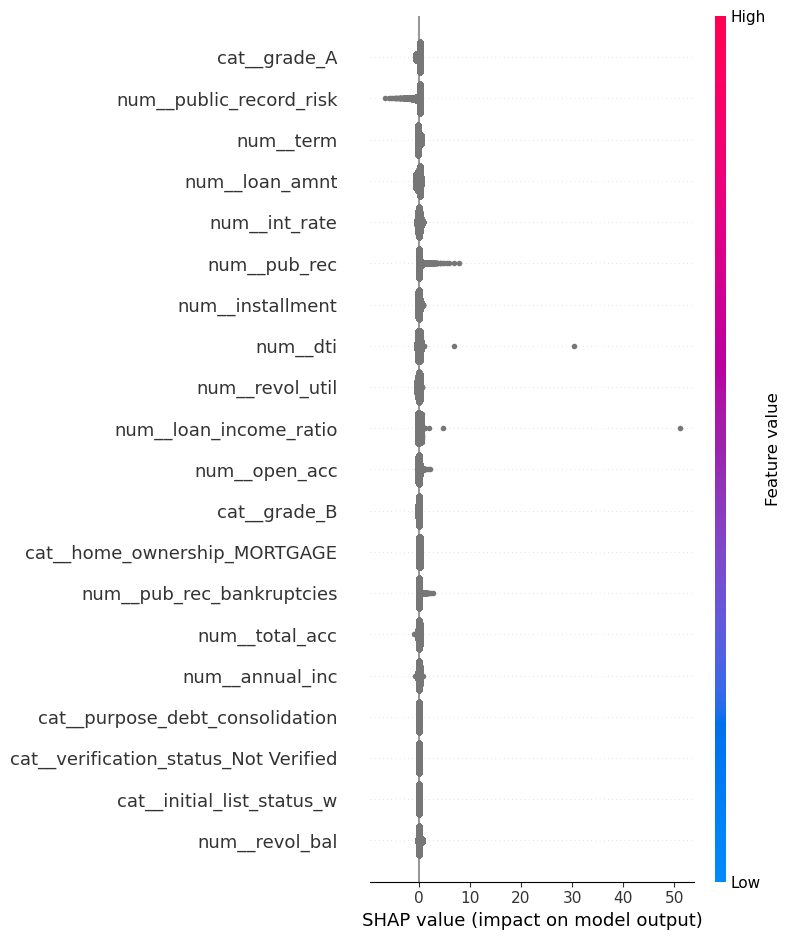

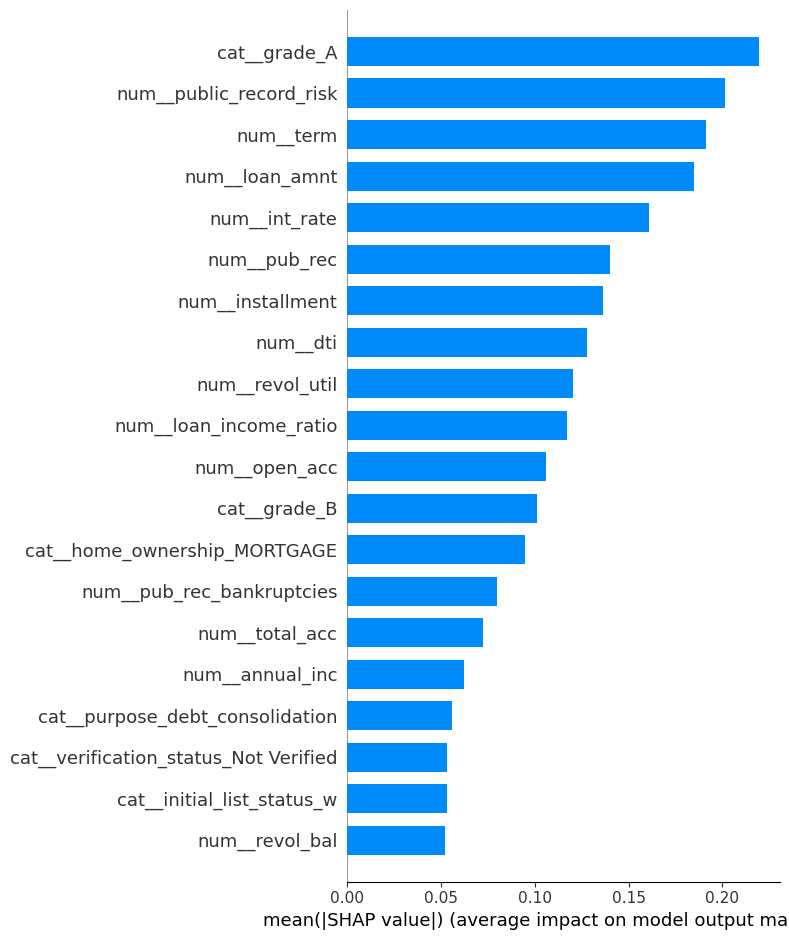

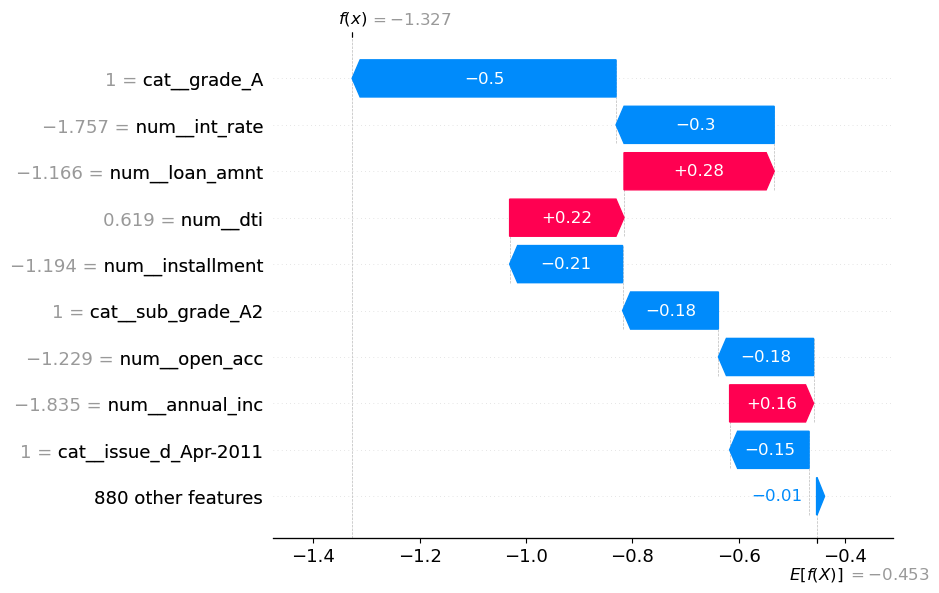

In [35]:
# ============================================
# SHAP Explainability for Logistic Regression
# ============================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# Extract model and preprocessor from pipeline
model = lr.named_steps['model']
preprocessor = lr.named_steps['preprocessor']

# Transform train and test data
X_train_processed = preprocessor.transform(x_train)
X_test_processed = preprocessor.transform(x_test)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Create SHAP explainer
explainer = shap.LinearExplainer(model, X_train_processed)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_processed)

# ============================
# SHAP Summary Plot (Beeswarm)
# ============================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.show()

# ============================
# SHAP Feature Importance (Bar)
# ============================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

sample_index = 0

sample = X_test_processed[sample_index]

if hasattr(sample, "toarray"):
    sample = sample.toarray().flatten()

waterfall_exp = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=sample,
    feature_names=feature_names
)

shap.plots.waterfall(waterfall_exp)

In [36]:
# Threshold Optimization
prob = lr.predict_proba(x_test)[:,1]
import pandas as pd
from sklearn.metrics import precision_score, recall_score

thresholds = [0.30, 0.40, 0.50, 0.60]

results = []

for t in thresholds:

    pred = (prob >= t).astype(int)

    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Approval Rate": (pred == 0).mean()
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,Approval Rate
0,0.3,0.239902,0.921403,0.246698
1,0.4,0.275395,0.820406,0.415713
2,0.5,0.319814,0.673576,0.586913
3,0.6,0.379343,0.486321,0.748554


In [43]:
# Business Impact Analysis
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

tn, fp, fn, tp = cm.ravel()

print(cm)

[[41416 22255]
 [ 5071 10464]]


In [50]:
y_prob = lr.predict_proba(x_test)[:,1]
print(y_prob[:10])
y_pred = (y_prob >= 0.5).astype(int)
print(y_pred[:10])
final_threshold = 0.45

[0.20963025 0.51135472 0.64716914 0.37686768 0.61144812 0.38653388
 0.68371082 0.25854952 0.48169097 0.44936635]
[0 1 1 0 1 0 1 0 0 0]


In [51]:
y_final = (y_prob >= final_threshold).astype(int)

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(cm)

[[41416 22255]
 [ 5071 10464]]


In [53]:
# Assumption
avg_loan_amount = 500000  # ₹5 lakh
loss_rate = 0.60         # 60% loss on default

baseline_loss = (tp + fn) * avg_loan_amount * loss_rate

model_loss = fn * avg_loan_amount * loss_rate

savings = baseline_loss - model_loss

print("Baseline Loss:", baseline_loss)
print("Model Loss:", model_loss)
print("Savings:", savings)

Baseline Loss: 4660500000.0
Model Loss: 1521300000.0
Savings: 3139200000.0


In [54]:
# Model Saving
import pickle

pickle.dump(lr, open("model.pkl", "wb"))

# Save preprocessor
pickle.dump(
    lr.named_steps["preprocessor"],
    open("preprocessor.pkl", "wb")
)

# Save logistic regression model only
pickle.dump(
    lr.named_steps["model"],
    open("logistic_model.pkl", "wb")
)

In [55]:
data.to_csv("credit_risk_model_dataset.csv", index=False)

In [56]:
for col in [
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'verification_status',
    'issue_d',
    'purpose',
    'earliest_cr_line',
    'initial_list_status',
    'application_type'
]:
    print(f"\n{col}")
    print(sorted(data[col].dropna().unique()))


grade
['A', 'B', 'C', 'D', 'E', 'F', 'G']

sub_grade
['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']

emp_length
['1 year', '10+ years', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '< 1 year']

home_ownership
['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']

verification_status
['Not Verified', 'Source Verified', 'Verified']

issue_d
['Apr-2008', 'Apr-2009', 'Apr-2010', 'Apr-2011', 'Apr-2012', 'Apr-2013', 'Apr-2014', 'Apr-2015', 'Apr-2016', 'Aug-2007', 'Aug-2008', 'Aug-2009', 'Aug-2010', 'Aug-2011', 'Aug-2012', 'Aug-2013', 'Aug-2014', 'Aug-2015', 'Aug-2016', 'Dec-2007', 'Dec-2008', 'Dec-2009', 'Dec-2010', 'Dec-2011', 'Dec-2012', 'Dec-2013', 'Dec-2014', 'Dec-2015', 'Dec-2016', 'Feb-2008', 'Feb-2009', 'Feb-2010', 'Feb-2011', 'Feb-2012', 'Feb-2013', 'Feb-2014', 'Feb-2015', 'Feb-201

In [57]:
print(x_train.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'loan_income_ratio', 'installment_income_ratio', 'has_bankruptcy', 'public_record_risk', 'high_utilization']
